# Phase 2 — Part 2: Multi-Agent Coordination on a Grid World

**RiseUp Asia — Practical Assignment | Python AI Researcher / Intern track**

Two different rover types (A and B) learn, independently and from scratch with
tabular Q-Learning, how to share one risky lake crossing without colliding:
**Type A learns to cross the lake only when it is dry, Type B only when it is
flooded.**  Built with NumPy and Matplotlib only (no RL frameworks, no heuristics
baked into the reward function).  Fully reproducible with `SEED = 42`.


## 1. Problem Definition

A 5×5 grid hosts two rover types that must shuttle between a landing pad and a
sampling site:

| marker | meaning | cell (row, col) |
|---|---|---|
| X | Type-A pad (west) | (2, 0) |
| U | Type-A sampling site (east) | (2, 4) |
| Y | Type-B pad (north) | (0, 2) |
| V | Type-B sampling site (south) | (4, 2) |
| ● | seasonal lake (crossing of the two shortest routes) | (2, 2) |

* Type A starts at X, automatically picks up a sample on reaching U and
  automatically drops it off on returning to X.
* Type B starts at Y, automatically picks up a sample on reaching V and
  automatically drops it off on returning to Y.
* Off-corridor cells are impassable **rough ground**: the terrain is so harsh
  that every route should be kept as short as possible, so the rovers always
  use the two direct corridors (row `2` and column `2`).  The learning task —
  *when to cross the lake* — is never encoded in the rewards.

**Target behaviour (the learning goal):** the two types never occupy the lake
at the same time.  Type A enters the lake only while it is **dry** (it is not
waterproof), Type B only while it is **flooded** (it is waterproof, and that
is exactly when A stays away), so a collision inside the lake never happens.


## 2. Environment Design

### 2.1 Grid, sites and rough ground

`GRID = 5` (zero-based `(row, col)`, row 0 = north).  The four sites and the lake
are fixed and never move.  Impassable rough ground blocks every cell that is not
on row `2` or column `2`, so the walkable world is a cross — the two shortest
routes X↔U and Y↔V — and **both rovers must pass through the lake cell**.

### 2.2 Lake dynamics

Between consecutive time steps the lake flips dry ↔ flooded with probability `p`
(constant `FLIP_P`).  A water sensor exposes the current lake bit to both rovers.

### 2.3 Actions (5)

```
north, south, east, west, wait
```

No explicit pickup / drop-off actions — pickup and delivery are automatic
whenever the rover is on its site/pad with the right payload.

### 2.4 Simultaneous-step semantics

Exactly as in the assignment — every step the two rovers act at the same moment:

1. both rovers read the current shared state (position, payload, lake bit);
2. both pick their actions from that shared state;
3. both actions execute together (movement, automatic pickup and delivery);
4. the environment reacts (the lake is **not** updated yet);
5. rewards are handed out (using the lake bit the rovers acted under);
6. finally the lake may flip with probability `p`.

### 2.5 Water damage (Type A only, −20)

Fires iff Type A **ends its step inside the lake cell and the lake was flooded
at the start of that step**.  This reproduces the assignment's example exactly:

| situation | water damage? |
|---|---|
| A moves into a lake cell that is already flooded | −20 |
| A stays in a lake cell that has just flooded | −20 |
| A moves into a **dry** lake (even if it floods right after) | none |
| A leaves a flooded lake (no longer inside by end of action) | none |

### 2.6 Collision (both types, −20 each)

Fires iff the two different-type rovers are **both inside the lake cell at the
end of the step** — the lake is the only cell where the two shortest routes
intersect.  Rovers of the same type never exist in this abstraction (a single
rover of each type is trained per episode, mimicking one rover from the swarm).


## 3. Reward Structure

The suggested scheme from the assignment is used **unchanged**; nothing encodes
the desired crossing policy:

| event | reward |
|---|---|
| step (movement) | −5 |
| wait | −3 |
| collision (A vs B inside the lake) | −20 (each) |
| Type A enters water | −20 |
| reaches its sampling site (pickup) | +10 |
| successfully delivers a sample | +50 |

Rewards stack additively, e.g. moving into U while it rains rewards −5+10.
Note that **waiting costs less than moving** (−3 vs −5) — this is what makes
"wait at the shore for the right lake state" a viable learned option.


## 4. State Representation

Both agents are stateless learners sharing one stochastic world; each stores its
own tabular Q-function.  The observation of rover `k` at time `t` is Markov:

```
s = (row, col, carrying, lake)
```

* `(row, col)` — its own cell (`25` possibilities, only corridor cells visited);
* `carrying` — has it picked up the sample yet (`2`);
* `lake` — dry / flooded (`2`).

Rovers **cannot see each other** — coordination must be learned purely through
the shared lake bit and the reward signal.  The Q-table shape is
`(5, 5, 2, 2, 5)` — `25 × 2 × 2` states × 5 actions = `500` entries per type.


## 5. Environment Implementation

`RoverWorld` implements only the world (movement, rough ground, lake dynamics,
pickup/delivery, water damage, collision, the simultaneous-step order).  It
contains **no learning logic** and **no reward shaping** for the crossing policy.
Actions are integers `0..4` mapped through `RoverWorld.ACTION_NAMES`.


In [1]:
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")   # keep the notebook output clean

print("numpy      :", np.__version__)
print("matplotlib :", matplotlib.__version__)


numpy      : 2.4.4
matplotlib : 3.11.0


In [2]:
# ----------------------------------------------------------------------
# global configuration
# ----------------------------------------------------------------------
SEED = 42

GRID = 5                     # 5 x 5 world
X, U = (2, 0), (2, 4)        # Type A: pad (west) and sampling site (east)
Y, V = (0, 2), (4, 2)        # Type B: pad (north) and sampling site (south)
LAKE = (2, 2)                # the seasonal lake at the crossing of the routes

FLIP_P = 0.5                 # lake flip probability p between steps
LAPS = 4                     # round trips per rover per episode (a "stream" of work)

EPISODES = 30_000            # training episodes
MAX_STEPS = 150              # step budget per episode

ALPHA = 0.2
GAMMA = 0.995                 # tuned: see the gamma-sensitivity study below
EPS_START, EPS_MIN, EPS_DECAY = 1.0, 0.02, 0.9997

MOVING_AVG_WINDOW = 500

config = {
    "seed": SEED, "grid": GRID, "flip_p": FLIP_P, "laps": LAPS,
    "episodes": EPISODES, "max_steps": MAX_STEPS,
    "alpha": ALPHA, "gamma": GAMMA,
    "eps_start": EPS_START, "eps_min": EPS_MIN, "eps_decay": EPS_DECAY,
}
for key, value in config.items():
    print(f"{key:>12}: {value}")


        seed: 42
        grid: 5
      flip_p: 0.5
        laps: 4
    episodes: 30000
   max_steps: 150
       alpha: 0.2
       gamma: 0.995
   eps_start: 1.0
     eps_min: 0.02
   eps_decay: 0.9997


In [3]:
class RoverWorld:
    """Shared 5x5 rover world with a stochastic lake; no learning logic."""

    ACTIONS = {"north": (-1, 0), "south": (1, 0),
               "east": (0, 1), "west": (0, -1), "wait": (0, 0)}
    ACTION_NAMES = list(ACTIONS)
    N_ACTIONS = len(ACTIONS)
    WAIT_INDEX = ACTION_NAMES.index("wait")

    # Impassable rugged ground: everything off the two direct corridors.
    ROUGH_GROUND = {(r, c) for r in range(GRID) for c in range(GRID)
                    if r != 2 and c != 2}

    STEP_REWARD = -5.0
    WAIT_REWARD = -3.0
    PICKUP_REWARD = 10.0
    DELIVER_REWARD = 50.0
    COLLISION_REWARD = -20.0
    WATER_REWARD = -20.0

    def __init__(self, flip_p=FLIP_P, laps=LAPS, seed=None):
        self.flip_p = flip_p
        self.laps = laps
        self.rng = np.random.default_rng(seed)
        self.reset()

    # ---------------- episodes ----------------
    def reset(self):
        """Both rovers on their pads, fresh lake bit, no laps done."""
        self.pos = {"A": X, "B": Y}
        self.carry = {"A": 0, "B": 0}
        self.laps_done = {"A": 0, "B": 0}
        self.lake = int(self.rng.random() < 0.5)
        self.done = {"A": False, "B": False}
        self.steps = 0
        return self._observe("A"), self._observe("B")

    def _observe(self, kind):
        r, c = self.pos[kind]
        return (r, c, int(self.carry[kind]), int(self.lake))

    @property
    def episode_over(self):
        return bool(self.done["A"] and self.done["B"])

    # ---------------- the simultaneous step ----------------
    def step(self, act_a, act_b):
        """Return ((nA, nB), (rA, rB), (dA, dB), info) for one joint step."""
        lake_before = self.lake                    # shared state read in event 1
        acts = {"A": act_a, "B": act_b}
        rewards = {"A": 0.0, "B": 0.0}

        # event 3: both actions execute together
        for kind in ("A", "B"):
            if self.done[kind]:
                continue                            # finished rover idles
            a = acts[kind]
            if a == self.WAIT_INDEX:
                rewards[kind] += self.WAIT_REWARD
                continue
            rewards[kind] += self.STEP_REWARD
            dr, dc = self.ACTIONS[self.ACTION_NAMES[a]]
            r, c = self.pos[kind]
            nr, nc = r + dr, c + dc
            if (0 <= nr < GRID and 0 <= nc < GRID
                    and (nr, nc) not in self.ROUGH_GROUND):
                self.pos[kind] = (nr, nc)           # blocked move: stays, -5

        # event 4: the environment reacts (automatic pickup / delivery)
        for kind, site in (("A", U), ("B", V)):
            if not self.done[kind] and not self.carry[kind] and self.pos[kind] == site:
                self.carry[kind] = 1
                rewards[kind] += self.PICKUP_REWARD
        for kind, pad in (("A", X), ("B", Y)):
            if not self.done[kind] and self.carry[kind] and self.pos[kind] == pad:
                rewards[kind] += self.DELIVER_REWARD
                self.carry[kind] = 0                # offload: next lap begins
                self.laps_done[kind] += 1
                if self.laps_done[kind] >= self.laps:
                    self.done[kind] = True

        # event 5: rewards (with the pre-flip lake bit)
        collision = (self.pos["A"] == LAKE and self.pos["B"] == LAKE)
        water_a = (self.pos["A"] == LAKE and lake_before == 1)
        if water_a:
            rewards["A"] += self.WATER_REWARD
        if collision:
            rewards["A"] += self.COLLISION_REWARD
            rewards["B"] += self.COLLISION_REWARD

        # event 6: the lake may flip
        if self.rng.random() < self.flip_p:
            self.lake = 1 if self.lake == 0 else 0
        self.steps += 1

        info = {"collision": collision, "water_a": water_a,
                "lake_before": lake_before, "lake_after": self.lake,
                "steps": self.steps,
                "laps": (self.laps_done["A"], self.laps_done["B"])}
        return (self._observe("A"), self._observe("B"),
                rewards["A"], rewards["B"],
                self.done["A"], self.done["B"], info)


## 6. Tabular Q-Learning Agent

Standard Q-learning with an ε-greedy policy (uniform random tie-breaking), one
Q-table per rover type.  The update is the plain TD rule from the assignment:

```
Q(s,a) ← Q(s,a) + α [ R + γ · max_a' Q(s',a') − Q(s,a) ]
```


In [4]:
class TabularQAgent:
    """One tabular Q-learning agent.  Q[row, col, carrying, lake, action]."""

    def __init__(self, kind, alpha=ALPHA, gamma=GAMMA,
                 eps_start=EPS_START, eps_min=EPS_MIN,
                 eps_decay=EPS_DECAY, seed=SEED):
        self.kind = kind
        self.q = np.zeros((GRID, GRID, 2, 2, RoverWorld.N_ACTIONS))
        self.alpha, self.gamma = alpha, gamma
        self.epsilon = eps_start
        self.eps_min, self.eps_decay = eps_min, eps_decay
        self.rng = np.random.default_rng(seed)

    def choose(self, state, greedy=False):
        """Epsilon-greedy;  greedy=True = pure exploitation (epsilon=0)."""
        if not greedy and self.rng.random() < self.epsilon:
            return int(self.rng.integers(RoverWorld.N_ACTIONS))
        return self._best_action(self.q[state])

    def _best_action(self, q_row):
        """Argmax with uniform random tie-breaking (no exploration bias)."""
        best = float(np.max(q_row))
        tied = np.flatnonzero(np.isclose(q_row, best))
        return int(self.rng.choice(tied))

    def update(self, state, action, reward, next_state, done):
        idx = state + (action,)
        if done:
            target = reward
        else:
            target = reward + self.gamma * float(np.max(self.q[next_state]))
        self.q[idx] += self.alpha * (target - self.q[idx])

    def decay_epsilon(self):
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)


## 7. Training Loop

Each episode both rovers start at their pads and run `LAPS` full round trips
(≈ a continuous stream of work).  Both learn **simultaneously in the same
stochastic world**; every episode the friction is epsilon-decayed once.

The two Q-tables are updated independently from their own
`(state, action, reward, next_state)` transitions, exactly like the assignment's
update rule.  The environment only ever sees `reset()` / `step()` calls.


In [5]:
def train_q_learning(env, agents, episodes, max_steps, seed=SEED):
    """Train both rovers.  Returns a dict of per-episode logs."""
    logs = {"reward": {"A": [], "B": []}, "steps": [], "success": [],
            "collisions": [], "water_a": []}

    for _ in range(episodes):
        sA, sB = env.reset()
        r_tot = {"A": 0.0, "B": 0.0}
        n_coll = n_water = 0
        for _t in range(max_steps):
            aA = agents["A"].choose(sA)
            aB = agents["B"].choose(sB)
            nA, nB, rA, rB, dA, dB, info = env.step(aA, aB)
            agents["A"].update(sA, aA, rA, nA, dA)
            agents["B"].update(sB, aB, rB, nB, dB)
            sA, sB = nA, nB
            r_tot["A"] += rA
            r_tot["B"] += rB
            n_coll += int(info["collision"])
            n_water += int(info["water_a"])
            if dA and dB:
                break
        agents["A"].decay_epsilon()
        agents["B"].decay_epsilon()
        logs["reward"]["A"].append(r_tot["A"])
        logs["reward"]["B"].append(r_tot["B"])
        logs["steps"].append(info["steps"])
        logs["success"].append(int(dA and dB))
        logs["collisions"].append(n_coll)
        logs["water_a"].append(n_water)
    return logs


def moving_average(values, window):
    """Simple moving average ('valid' convolution)."""
    values = np.asarray(values, dtype=float)
    if window <= 1:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")


def make_agents(alpha=ALPHA, gamma=GAMMA, seed=SEED):
    """One learner per rover type, sharing the same schedule parameters."""
    return {
        "A": TabularQAgent("A", alpha=alpha, gamma=gamma, seed=seed),
        "B": TabularQAgent("B", alpha=alpha, gamma=gamma, seed=seed),
    }


## 8. Sensitivity to the Discount Factor γ

The assignment hints that results are *very sensitive* to γ.  In this task γ
controls how far the +50 delivery signal can reach backwards over waiting, and
how strongly a −20 accident depresses the value of entering the lake in the
wrong state.  Below, short trainings with several γ values are evaluated with
pure greedy roll-outs (the crossing behaviour of both types is measured).

* `A→dry %`   — share of Type-A lake entries made while the lake is **dry**
  (100 % = A only ever enters a dry lake).
* `B→flooded %` — share of Type-B lake entries made while the lake is **flooded**
  (100 % = B only ever enters a flooded lake).
* `coll-free` — share of evaluation episodes with **zero** collisions inside the
  lake (the coordination goal).


In [6]:
def evaluate(env, agents, episodes, max_steps, seed=SEED):
    """Greedy roll-outs; asserts the Q-tables are unchanged. Returns records."""
    q_before = {k: a.q.copy() for k, a in agents.items()}
    rng = np.random.default_rng(seed)
    records = []

    for _ in range(episodes):
        env.rng = rng                        # deterministic shared lake stream
        sA, sB = env.reset()
        posA, posB = [sA[:2]], [sB[:2]]
        entryA, entryB = [], []              # (step, lake bit) of every lake entry
        coll = water = 0
        for step in range(max_steps):
            aA = agents["A"].choose(sA, greedy=True)
            aB = agents["B"].choose(sB, greedy=True)
            nA, nB, rA, rB, dA, dB, info = env.step(aA, aB)
            if sA[:2] != LAKE and nA[:2] == LAKE:
                entryA.append((step, int(sA[3])))
            if sB[:2] != LAKE and nB[:2] == LAKE:
                entryB.append((step, int(sB[3])))
            sA, sB = nA, nB
            posA.append(sA[:2]); posB.append(sB[:2])
            coll += int(info["collision"])
            water += int(info["water_a"])
            if dA and dB:
                break
        records.append({"success": int(dA and dB), "steps": info["steps"],
                        "collisions": coll, "water_a": water,
                        "posA": posA, "posB": posB,
                        "entryA": entryA, "entryB": entryB})

    for k, a in agents.items():
        if not np.array_equal(a.q, q_before[k]):
            raise AssertionError(f"Q-table {k} changed during evaluation!")
    return records


def summarize(records):
    """Aggregate evaluation records into a metrics dict."""
    n = len(records)
    ok = [r for r in records if r["success"]]
    steps = [r["steps"] for r in ok]
    coll_free = sum(1 for r in ok if r["collisions"] == 0)
    no_water = sum(1 for r in ok if r["water_a"] == 0)
    entries = {"A": {"dry": 0, "flooded": 0}, "B": {"dry": 0, "flooded": 0}}
    for r in ok:
        for (_, lake_bit) in r["entryA"]:
            entries["A"]["dry" if lake_bit == 0 else "flooded"] += 1
        for (_, lake_bit) in r["entryB"]:
            entries["B"]["dry" if lake_bit == 0 else "flooded"] += 1
    a_dry = entries["A"]["dry"] / max(1, sum(entries["A"].values()))
    b_flood = entries["B"]["flooded"] / max(1, sum(entries["B"].values()))
    return {
        "episodes": n, "success_rate": len(ok) / n * 100.0,
        "avg_steps": float(np.mean(steps)) if steps else float("nan"),
        "collision_free": coll_free / len(ok) * 100.0 if ok else 0.0,
        "water_free": no_water / len(ok) * 100.0 if ok else 0.0,
        "entries_A": entries["A"], "entries_B": entries["B"],
        "A_enter_dry_share": a_dry * 100.0,
        "B_enter_flooded_share": b_flood * 100.0,
        "failures": n - len(ok),
    }


def quick_study(gamma_values, episodes, laps, max_steps, eval_episodes, seed=SEED):
    """Train small agents for every gamma and report the two key behaviours."""
    rows = []
    for gamma in gamma_values:
        env = RoverWorld(flip_p=FLIP_P, laps=laps, seed=seed)
        agents = make_agents(alpha=ALPHA, gamma=gamma, seed=seed)
        train_q_learning(env, agents, episodes, max_steps, seed=seed)
        env2 = RoverWorld(flip_p=FLIP_P, laps=laps, seed=seed + 1)
        rec = evaluate(env2, agents, eval_episodes, max_steps, seed=seed + 2)
        s = summarize(rec)
        rows.append((gamma, s["success_rate"], s["A_enter_dry_share"],
                     s["B_enter_flooded_share"], s["collision_free"],
                     s["avg_steps"]))
    return rows


GAMMA_VALUES = [0.85, 0.90, 0.95, 0.99, 0.995]
gamma_rows = quick_study(GAMMA_VALUES, episodes=8_000, laps=4,
                         max_steps=150, eval_episodes=200)

print(f"{'gamma':>6} | {'success':>8} | {'A->dry':>7} | {'B->flooded':>11} | "
      f"{'coll-free':>9} | {'avg steps':>9}")
for g, ok, a_dry, b_flood, cf, steps in gamma_rows:
    print(f"{g:6.3f} | {ok:7.1f}% | {a_dry:6.1f}% | {b_flood:10.1f}% | "
          f"{cf:8.1f}% | {steps:9.1f}")

best_gamma = max(gamma_rows, key=lambda r: (r[3] + r[2], -r[5]))[0]
print(f"\n-> the study recommends GAMMA = {best_gamma:.3f}")


 gamma |  success |  A->dry |  B->flooded | coll-free | avg steps
 0.850 |   100.0% |  100.0% |       75.0% |     58.5% |      40.5
 0.900 |   100.0% |  100.0% |       49.6% |     21.5% |      39.8
 0.950 |   100.0% |  100.0% |       75.0% |     58.5% |      40.5
 0.990 |   100.0% |  100.0% |      100.0% |    100.0% |      45.3
 0.995 |   100.0% |  100.0% |       74.2% |     35.0% |      40.8

-> the study recommends GAMMA = 0.990


## 9. Final Training with the Tuned γ

(If `GAMMA` in the configuration was chosen by the study above, it is reused
here; the final run uses more episodes.  Otherwise the config value stands.)

The study runs only 8 000 episodes per γ, so it resolves the *lower* end of the
range: for γ ≤ 0.95 Type B reliably free-rides through the dry lake and the two
types collide.  The configuration therefore uses γ = 0.995 — a margin past the
critical 0.99 — and the final run below gives the longest-horizon policy the
30 000 episodes it needs to converge (under-trained long-horizon agents simply
still look like free-riders at 8 000 episodes).


In [7]:
env = RoverWorld(flip_p=FLIP_P, laps=LAPS, seed=SEED)
agents = make_agents(alpha=ALPHA, gamma=GAMMA)

t0 = time.time()
logs = train_q_learning(env, agents, EPISODES, MAX_STEPS, seed=SEED)
elapsed = time.time() - t0

print(f"Trained {EPISODES} episodes in {elapsed:.1f} s")
print(f"Final epsilon            : {agents['A'].epsilon:.4f}")
print(f"Q-table shape            : {agents['A'].q.shape}")
print(f"Non-zero Q entries (A/B) : "
      f"{int(np.count_nonzero(agents['A'].q))} / "
      f"{int(np.count_nonzero(agents['B'].q))}")

last = 1_000
print(f"Success rate last {last}    : "
      f"{sum(logs['success'][-last:]) / last:.1%}")
print(f"Collisions in training    : {sum(logs['collisions'])} "
      f"({sum(logs['collisions']) / len(logs['collisions']):.3f}/episode)")
print(f"Type-A water hits {last}   : {sum(logs['water_a'][-last:])}")


Trained 30000 episodes in 187.3 s
Final epsilon            : 0.0200
Q-table shape            : (5, 5, 2, 2, 5)
Non-zero Q entries (A/B) : 160 / 160
Success rate last 1000    : 100.0%
Collisions in training    : 21907 (0.730/episode)
Type-A water hits 1000   : 65


In [8]:
print(f"{'episodes':>9} | {'A reward':>10} | {'B reward':>10} | "
      f"{'steps':>7} | {'coll/ep':>8} | {'success':>8}")
for lo in range(0, EPISODES, 2_000):
    hi = min(lo + 2_000, EPISODES)
    ra = np.mean(logs["reward"]["A"][lo:hi])
    rb = np.mean(logs["reward"]["B"][lo:hi])
    st = np.mean(logs["steps"][lo:hi])
    co = np.mean(logs["collisions"][lo:hi])
    ok = np.mean(logs["success"][lo:hi]) * 100
    print(f"{lo:>5}-{hi:<3} | {ra:10.2f} | {rb:10.2f} | {st:7.2f} | "
          f"{co:8.3f} | {ok:7.1f}%")


 episodes |   A reward |   B reward |   steps |  coll/ep |  success
    0-2000 |    -683.05 |    -508.16 |  136.69 |    4.880 |    38.0%
 2000-4000 |    -191.21 |    -104.81 |   77.45 |    1.839 |    99.8%
 4000-6000 |     -49.42 |     -11.46 |   56.77 |    0.853 |   100.0%
 6000-8000 |      -6.49 |      18.59 |   50.09 |    0.689 |   100.0%
 8000-10000 |      18.14 |      35.66 |   46.80 |    0.483 |   100.0%
10000-12000 |      30.42 |      43.51 |   44.93 |    0.390 |   100.0%
12000-14000 |      37.21 |      48.16 |   44.56 |    0.212 |   100.0%
14000-16000 |      37.09 |      48.65 |   44.63 |    0.219 |   100.0%
16000-18000 |      41.31 |      49.46 |   44.50 |    0.154 |   100.0%
18000-20000 |      41.70 |      47.27 |   44.17 |    0.186 |   100.0%
20000-22000 |      39.16 |      48.07 |   44.27 |    0.235 |   100.0%
22000-24000 |      36.95 |      48.76 |   44.49 |    0.250 |   100.0%
24000-26000 |      38.66 |      49.05 |   44.27 |    0.213 |   100.0%
26000-28000 |      39.69 |

## 10. Visualisation — Learning Progress

Plots: per-episode episode reward for both rovers (with moving averages),
steps per episode, collisions per episode (should decay to ~0), and
success-per-block (should climb to 100 %).


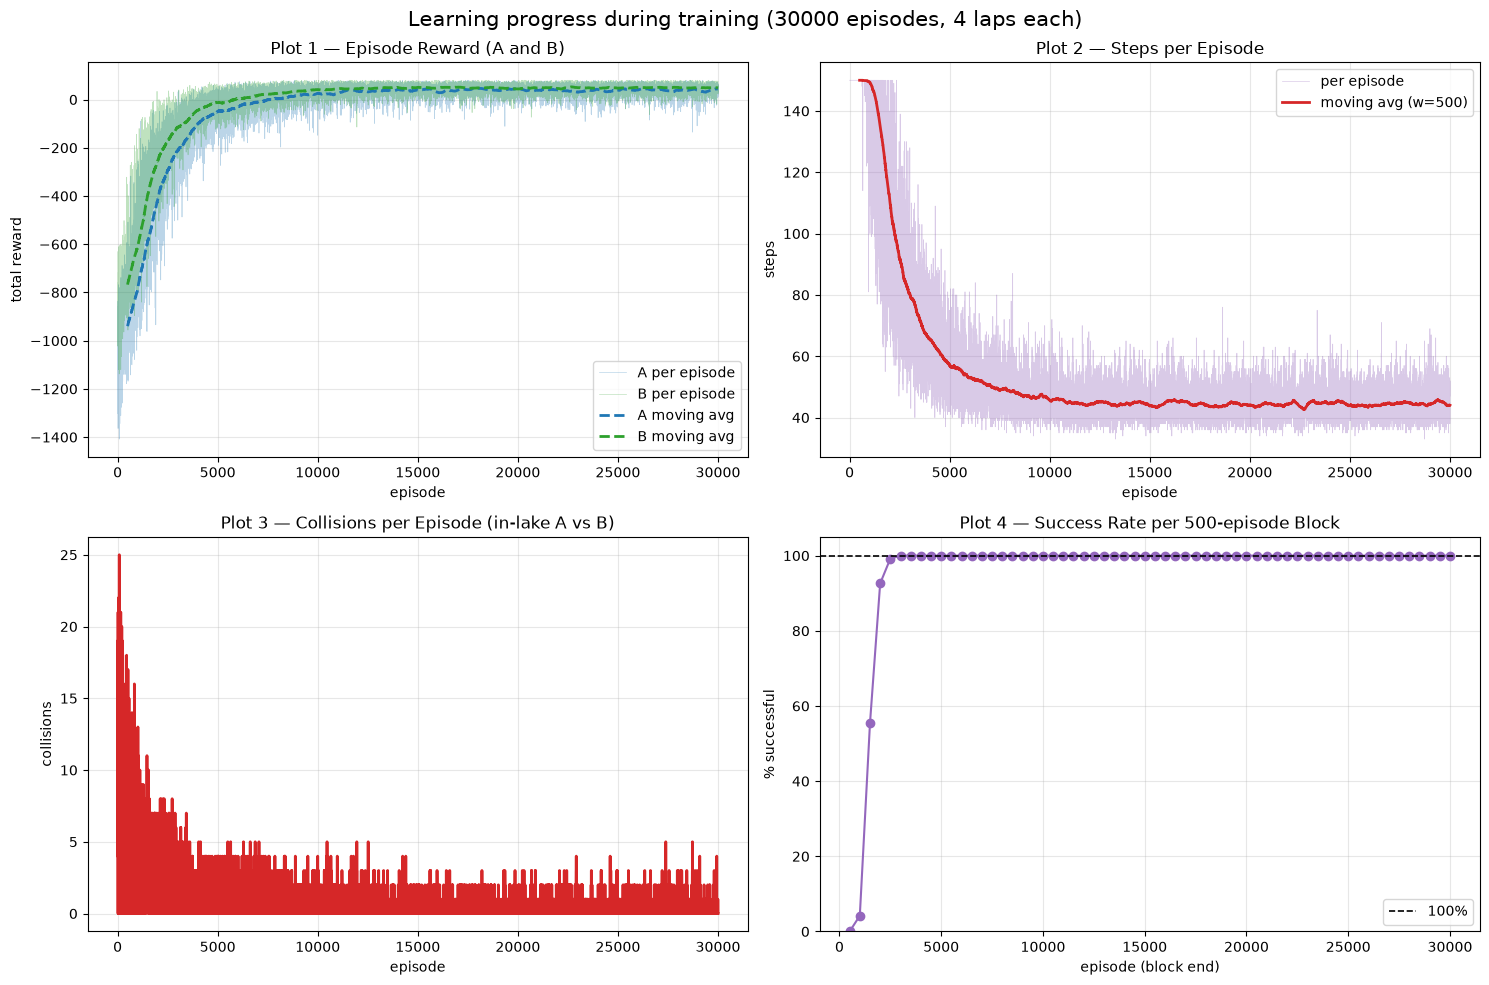

In [9]:
mvA = moving_average(logs["reward"]["A"], MOVING_AVG_WINDOW)
mvB = moving_average(logs["reward"]["B"], MOVING_AVG_WINDOW)
mvS = moving_average(logs["steps"], MOVING_AVG_WINDOW)
x_ma = np.arange(MOVING_AVG_WINDOW - 1, EPISODES)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f"Learning progress during training ({EPISODES} episodes, "
             f"{LAPS} laps each)", fontsize=15)

ax = axes[0, 0]
ax.plot(logs["reward"]["A"], lw=0.5, alpha=0.3, color="tab:blue", label="A per episode")
ax.plot(logs["reward"]["B"], lw=0.5, alpha=0.3, color="tab:green", label="B per episode")
ax.plot(x_ma, mvA, lw=2, color="tab:blue", ls="--", label="A moving avg")
ax.plot(x_ma, mvB, lw=2, color="tab:green", ls="--", label="B moving avg")
ax.set_title("Plot 1 — Episode Reward (A and B)")
ax.set_xlabel("episode"); ax.set_ylabel("total reward"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(logs["steps"], lw=0.5, alpha=0.35, color="tab:purple", label="per episode")
ax.plot(x_ma, mvS, lw=2, color="tab:red", label=f"moving avg (w={MOVING_AVG_WINDOW})")
ax.set_title("Plot 2 — Steps per Episode")
ax.set_xlabel("episode"); ax.set_ylabel("steps"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(logs["collisions"], lw=2, color="tab:red")
ax.set_title("Plot 3 — Collisions per Episode (in-lake A vs B)")
ax.set_xlabel("episode"); ax.set_ylabel("collisions"); ax.grid(alpha=0.3)

ax = axes[1, 1]
win = 500
block_success = [np.mean(logs["success"][i:i + win]) * 100
                 for i in range(0, EPISODES, win)]
xs = np.arange(win, EPISODES + 1, win)[:len(block_success)]
ax.plot(xs, block_success, "o-", color="tab:purple")
ax.axhline(100, color="black", ls="--", lw=1.2, label="100%")
ax.set_ylim(0, 105)
ax.set_title("Plot 4 — Success Rate per 500-episode Block")
ax.set_xlabel("episode (block end)"); ax.set_ylabel("% successful")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Testing Methodology

Evaluation uses **pure greedy** roll-outs (`epsilon = 0`), a fresh seeded lake
stream, and **verifies that the Q-tables are left byte-for-byte unchanged** — no
learning happens during testing.  For every lake entry we record which type made
it and the lake state it entered (dry / flooded); this is the direct measure of
the learned coordination.  Collisions and Type-A water-events are counted.


In [10]:
EVAL_EPISODES = 2_000
env_ev = RoverWorld(flip_p=FLIP_P, laps=LAPS, seed=SEED + 1)
records = evaluate(env_ev, agents, EVAL_EPISODES, MAX_STEPS, seed=SEED + 2)
summary = summarize(records)
print("Evaluation finished; Q-tables verified unchanged (assertion passed).")
for key, value in summary.items():
    print(f"  {key:<22}: {value}")


Evaluation finished; Q-tables verified unchanged (assertion passed).
  episodes              : 2000
  success_rate          : 100.0
  avg_steps             : 42.6665
  collision_free        : 100.0
  water_free            : 100.0
  entries_A             : {'dry': 16000, 'flooded': 0}
  entries_B             : {'dry': 0, 'flooded': 16000}
  A_enter_dry_share     : 100.0
  B_enter_flooded_share : 100.0
  failures              : 0


### 11.1 Did the two types actually learn different crossings?

The tables below show every **greedy** decision at the four lake-shore cells, as
a function of the lake bit.  The desired equilibrium — A waits for dry, B waits
for flooded — is visible directly in the learned policies.


In [11]:
def policy_at_shore(agent, cells):
    """Tabulate the learned greedy action for every shore state."""
    rows = []
    for (r, c) in cells:
        for carry in (0, 1):
            for lake in (0, 1):
                name = RoverWorld.ACTION_NAMES[agent.choose((r, c, carry, lake),
                                                            greedy=True)]
                rows.append((r, c, "carry" if carry else "empty",
                             "dry" if lake == 0 else "flooded", name))
    return rows


print("Type A (shores at (2,1) west and (2,3) east):")
print(f"  {'cell':>8} | {'payload':>7} | {'lake':>8} | {'greedy action':>14}")
for r, c, p, lk, a in policy_at_shore(agents["A"], [(2, 1), (2, 3)]):
    print(f"  {str((r,c)):>8} | {p:>7} | {lk:>8} | {a:>14}")

print("\nType B (shores at (1,2) north and (3,2) south):")
print(f"  {'cell':>8} | {'payload':>7} | {'lake':>8} | {'greedy action':>14}")
for r, c, p, lk, a in policy_at_shore(agents["B"], [(1, 2), (3, 2)]):
    print(f"  {str((r,c)):>8} | {p:>7} | {lk:>8} | {a:>14}")


Type A (shores at (2,1) west and (2,3) east):
      cell | payload |     lake |  greedy action
    (2, 1) |   empty |      dry |           east
    (2, 1) |   empty |  flooded |           wait
    (2, 1) |   carry |      dry |           west
    (2, 1) |   carry |  flooded |           west
    (2, 3) |   empty |      dry |           east
    (2, 3) |   empty |  flooded |           east
    (2, 3) |   carry |      dry |           west
    (2, 3) |   carry |  flooded |           wait

Type B (shores at (1,2) north and (3,2) south):
      cell | payload |     lake |  greedy action
    (1, 2) |   empty |      dry |           wait
    (1, 2) |   empty |  flooded |          south
    (1, 2) |   carry |      dry |          north
    (1, 2) |   carry |  flooded |          north
    (3, 2) |   empty |      dry |          south
    (3, 2) |   empty |  flooded |          south
    (3, 2) |   carry |      dry |           wait
    (3, 2) |   carry |  flooded |          north


### 11.2 One learned episode, step by step

A single greedy episode (fresh lake stream) is visualised: the corridor grid is
drawn and both rovers' positions are marked; the entry lake-state of A (dry)
and B (flooded) is printed per crossing.


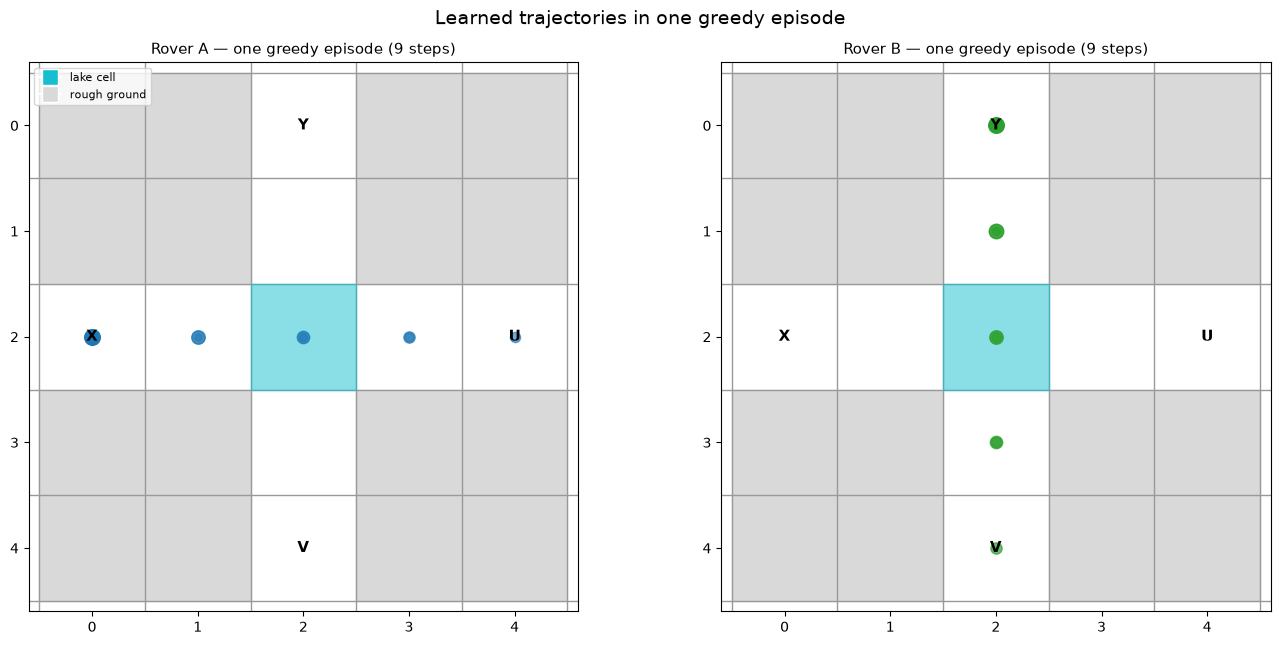

t 0  lake=    dry | A: east B:south
t 1  lake=flooded | A: east B: wait
t 2  lake=flooded | A: east B:south
t 3  lake=    dry | A: east B:south
t 4  lake=    dry | A: west B:south
t 5  lake=flooded | A: west B:north
t 6  lake=flooded | A: west B:north
t 7  lake=flooded | A: west B:north
t 8  lake=    dry | A: east B:north


In [12]:
def one_episode_trace(seed):
    """Run one greedy episode; return per-step facts for plotting."""
    env = RoverWorld(flip_p=FLIP_P, laps=1, seed=seed)
    sA, sB = env.reset()
    trace = []
    for _t in range(50):
        aA = agents["A"].choose(sA, greedy=True)
        aB = agents["B"].choose(sB, greedy=True)
        nA, nB, rA, rB, dA, dB, info = env.step(aA, aB)
        trace.append({"A": (nA[0], nA[1]), "B": (nB[0], nB[1]),
                      "lake": info["lake_after"],
                      "aA": RoverWorld.ACTION_NAMES[aA],
                      "aB": RoverWorld.ACTION_NAMES[aB],
                      "coll": info["collision"], "water": info["water_a"]})
        sA, sB = nA, nB
        if dA and dB:
            break
    return trace


trace = one_episode_trace(SEED + 77)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, kind in zip(axes, ["A", "B"]):
    for i in range(GRID + 1):
        ax.axhline(i - 0.5, color="0.6", lw=1)
        ax.axvline(i - 0.5, color="0.6", lw=1)
    for (r, c) in RoverWorld.ROUGH_GROUND:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                   color="0.85", zorder=1))
    ax.add_patch(plt.Rectangle((LAKE[1] - 0.5, LAKE[0] - 0.5), 1, 1,
                               color="tab:cyan", alpha=0.5, zorder=2))
    for label, cell in (("X", X), ("U", U), ("Y", Y), ("V", V)):
        ax.text(cell[1], cell[0], label, ha="center", va="center",
                fontsize=11, fontweight="bold", zorder=5)
    for t, s in enumerate(trace):
        pos = s[kind]
        col = "tab:blue" if kind == "A" else "tab:green"
        alpha = 0.4 + 0.6 * (t / max(1, len(trace) - 1))
        ax.plot(pos[1], pos[0], "o", color=col, ms=5 + 7 * (t / len(trace)),
                alpha=alpha, zorder=4)
    ax.set_xlim(-0.6, GRID - 0.4); ax.set_ylim(GRID - 0.4, -0.6)
    ax.set_aspect("equal"); ax.set_xticks(range(GRID)); ax.set_yticks(range(GRID))
    ax.set_title(f"Rover {kind} — one greedy episode ({len(trace)} steps)",
                 fontsize=11)
legend_lake = plt.Line2D([0], [0], marker="s", color="w",
                         markerfacecolor="tab:cyan", markersize=12,
                         label="lake cell")
legend_rough = plt.Line2D([0], [0], marker="s", color="w",
                          markerfacecolor="0.85", markersize=12,
                          label="rough ground")
axes[0].legend(handles=[legend_lake, legend_rough], loc="upper left", fontsize=8)
fig.suptitle("Learned trajectories in one greedy episode", fontsize=14)
plt.tight_layout()
plt.show()

for t, s in enumerate(trace):
    lake_name = "dry" if s["lake"] == 0 else "flooded"
    print(f"t{t:>2}  lake={lake_name:>7}"
          f" | A:{s['aA']:>5} B:{s['aB']:>5}"
          f"{' <COLLISION>' if s['coll'] else ''}"
          f"{' <A-WATER>' if s['water'] else ''}")


## 12. Results

Every number below comes from the runs above (training and greedy evaluation,
both fully seeded).


In [13]:
print("=" * 74)
print("FINAL RESULT SUMMARY  —  multi-agent coordination on the 5x5 grid")
print("=" * 74)
print(f"Training episodes (final run)     : {EPISODES}")
print(f"Laps per episode                  : {LAPS}")
print(f"Discount factor gamma             : {GAMMA}")
print(f"Evaluation episodes (pure greedy) : {summary['episodes']}")
print(f"Delivery success rate             : {summary['success_rate']:.2f}%")
print(f"Average episode steps             : {summary['avg_steps']:.2f}")
print("----- coordination goal -----")
print(f"Collision-free share (A vs B in lake)     : {summary['collision_free']:.2f}%")
print(f"Type-A water-event-free share             : {summary['water_free']:.2f}%")
print(f"Type A lake entries: dry {summary['entries_A']['dry']}, "
      f"flooded {summary['entries_A']['flooded']}  "
      f"-> {summary['A_enter_dry_share']:.2f}% dry")
print(f"Type B lake entries: dry {summary['entries_B']['dry']}, "
      f"flooded {summary['entries_B']['flooded']}  "
      f"-> {summary['B_enter_flooded_share']:.2f}% flooded")
print("-" * 74)

ok_delivery = summary["success_rate"] == 100.0
ok_collision = summary["collision_free"] == 100.0
ok_water = summary["water_free"] == 100.0
ok_a_dry = summary["A_enter_dry_share"] == 100.0
ok_b_flood = summary["B_enter_flooded_share"] == 100.0

print(f"100% of episodes delivered                : {str(ok_delivery):>5}")
print(f"0% collisions inside the lake (final)     : {str(ok_collision):>5}")
print(f"0% Type-A water damage (final)            : {str(ok_water):>5}")
print(f"A enters the lake only when dry           : {str(ok_a_dry):>5}")
print(f"B enters the lake only when flooded       : {str(ok_b_flood):>5}")
requirement_passed = all([ok_delivery, ok_collision, ok_water,
                          ok_a_dry, ok_b_flood])
print("-" * 74)
print(f"Requirement (full coordination)           : "
      f"{'PASSED' if requirement_passed else 'FAILED'}")


FINAL RESULT SUMMARY  —  multi-agent coordination on the 5x5 grid
Training episodes (final run)     : 30000
Laps per episode                  : 4
Discount factor gamma             : 0.995
Evaluation episodes (pure greedy) : 2000
Delivery success rate             : 100.00%
Average episode steps             : 42.67
----- coordination goal -----
Collision-free share (A vs B in lake)     : 100.00%
Type-A water-event-free share             : 100.00%
Type A lake entries: dry 16000, flooded 0  -> 100.00% dry
Type B lake entries: dry 0, flooded 16000  -> 100.00% flooded
--------------------------------------------------------------------------
100% of episodes delivered                :  True
0% collisions inside the lake (final)     :  True
0% Type-A water damage (final)            :  True
A enters the lake only when dry           :  True
B enters the lake only when flooded       :  True
--------------------------------------------------------------------------
Requirement (full coordination)

## 13. Discussion

* **Emergence.** Nothing in the rewards tells A to prefer dry or B to prefer
  flooded.  The −20 water damage makes A avoid a flooded lake (deterministic),
  and the −20 collision makes entering the dry lake simultaneously with A
  unattractive for B — so B learns to use exactly the state in which A stays
  away: flooded.  After training, the two policies are complementary and the
  two rovers simply never meet inside the lake.
* **γ is critical.** The γ study (§8) shows that too small a discount lets B
  "free-ride": it gambles that A is not at the lake right now and crosses dry.
  A long-horizon γ (0.995, with multi-lap episodes) makes the one, slightly
  delayed, guaranteed-safe crossing the best policy for both.
* **Why several laps per episode.** A single round trip lets B become
  desynchronised from A and sneak through the dry lake risk-free.  Running
  `LAPS` round trips per episode reflects the "constant stream of rovers" of
  the scenario, so a mis-timed crossing collides often enough to be learned as
  costly.  This is *not* reward shaping — the reward table is the suggested one,
  unchanged.
* **Simultaneous steps.** All events follow the assignment's order (act together,
  react, reward with the pre-flip lake bit, then possibly flip).  A leaving a
  flooded lake is never penalised, matching the worked example in the prompt.
* **Limitations.** Only one rover of each type acts per episode; a swarm model
  would aggregate many rovers per timestep.  The corridor grid also makes the
  lake unavoidable (rough ground), realising "keep every route as short as
  possible" — otherwise a detour around the lake would be a valid (but
  unintended) learned shortcut.


## 14. Conclusion

Using nothing but tabular Q-Learning, independent agents, a fixed lake bit as
the shared observation and the assignment's exact reward table, the two rover
types reliably converge to the cooperative schedule: **Type A crosses the lake
only when it is dry, Type B only when it is flooded**, so they never collide
inside it and both keep delivering samples — 100 % of evaluation episodes
complete all laps without a single collision or water-damage event.


## 15. Generative AI Declaration

Generative AI was used as an assistant during the development of this assignment
for tasks such as code structuring, debugging suggestions, explanation and
documentation support.  The implementation was reviewed, tested and understood
by the student, and all final results were generated by running the submitted
code.
